# Importazione delle librerie


In [1]:

!pip install torchviz graphviz
!pip install torchview

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 112.3 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 req

In [2]:
import os
import sys
import subprocess

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
import torchvision


from torchsummary import summary
from torchviz import make_dot
from torchview import draw_graph

import sys
import subprocess

import matplotlib.pyplot as plt
import IPython.display as ipd
import graphviz
graphviz.set_jupyter_format('png')
from torchvision import models
import torchvision

import numpy as np
import pandas as pd



import librosa


from tqdm import tqdm
from torch.utils.data import Dataset, random_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

%matplotlib inline

# Selezione del dispositivo di calcolo


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Importazione del dataset


In questa **Fase 1** (baseline), il dataset RAVDESS viene suddiviso in modo **casuale** 
(random split, con seed fisso per aumentare la riproducibilità), indipendentemente dall'identità dello speaker.

Split utilizzato:
- Training: 70%
- Validation: 15%
- Test: 15%


In [4]:
def find_ravdess_dataset(base_dir="/kaggle/input"):
    ravdess_files = []
    for root, _, files in os.walk(base_dir):
        for filename in files:
            name = filename.lower()
            parts = filename.replace(".wav", "").split("-")
            if name.endswith(".wav") and len(parts) == 7 and parts[0] == "03":
                ravdess_files.append(os.path.join(root, filename))

    if not ravdess_files:
        raise FileNotFoundError(
            "Dataset RAVDESS non trovato in /kaggle/input. "
            "Aggiungi il dataset RAVDESS al notebook Kaggle e riesegui la cella."
        )

    return os.path.commonpath(ravdess_files)


DATASET_PATH = find_ravdess_dataset()
print(f"Percorso dataset RAVDESS trovato: {DATASET_PATH}")

emotion_map = {
    0: 'Neutral',
    1: 'Calm',
    2: 'Happy',
    3: 'Sad',
    4: 'Angry',
    5: 'Fearful',
    6: 'Disgust',
    7: 'Surprised'
}


Percorso dataset RAVDESS trovato: /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio


In [5]:
class RavdessDataset(Dataset):
    def __init__(self, root_dir=DATASET_PATH, subset="training"):
        """Dataset RAVDESS completo: in Fase 1 usiamo tutte le 8 emozioni disponibili."""
        self.root_dir = root_dir
        self._walker = []


        all_files = []
        for dirpath, _, filenames in os.walk(root_dir):
            for f in filenames:
                if f.endswith(".wav"):
                    all_files.append(os.path.join(dirpath, f))


        for file_path in all_files:
            filename = os.path.basename(file_path)


            parts = filename.replace(".wav", "").split("-")


            if len(parts) != 7:
                continue

            emotion = parts[2]


            self._walker.append(file_path)
    def __len__(self):
        return len(self._walker)

    def __getitem__(self, idx):
        file_path = self._walker[idx]
        waveform, sample_rate = torchaudio.load(file_path)


        filename = os.path.basename(file_path)
        parts = filename.replace(".wav", "").split("-")


        emotion_label = parts[2]
        utterance_number = int(parts[4])
        speaker_id = int(parts[6])


        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)


        wav_np = waveform.squeeze().numpy()


        wav_trimmed, _ = librosa.effects.trim(wav_np, top_db=30)


        wav_norm = librosa.util.normalize(wav_trimmed)


        waveform = torch.tensor(wav_norm).unsqueeze(0)

        resampler = T.Resample(orig_freq=sample_rate, new_freq=16000)
        waveform = resampler(waveform)
        sample_rate = 16000


        label_tensor = torch.tensor(int(emotion_label) - 1, dtype=torch.long)


        return waveform, sample_rate, label_tensor, speaker_id, utterance_number

In [6]:

full_dataset = RavdessDataset()
print(f"Totale campioni disponibili: {len(full_dataset)}")


total   = len(full_dataset)
n_train = int(0.70 * total)
n_val   = int(0.15 * total)
n_test  = total - n_train - n_val


generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [n_train, n_val, n_test], generator=generator
)

print(f"Training   : {len(train_dataset)} campioni  ({len(train_dataset)/total*100:.1f}%)")
print(f"Validation : {len(val_dataset)} campioni  ({len(val_dataset)/total*100:.1f}%)")
print(f"Testing    : {len(test_dataset)} campioni  ({len(test_dataset)/total*100:.1f}%)")
print()
print("Nota: la suddivisione è CASUALE (random split).")
print("La valutazione speaker-independent sarà implementata nella Fase 2.")


Totale campioni disponibili: 2880
Training   : 2015 campioni  (70.0%)
Validation : 432 campioni  (15.0%)
Testing    : 433 campioni  (15.0%)

Nota: la suddivisione è CASUALE (random split).
La valutazione speaker-independent sarà implementata nella Fase 2.


# Esplorazione dei dati


## Distribuzione delle classi per split

Questa cella confronta la distribuzione delle emozioni in training, validation e test. È utile per documentare se lo split random mantiene un bilanciamento ragionevole tra le classi.


,Train,Validation,Test
Neutral,132,33,27
Calm,262,59,63
Happy,273,55,56
Sad,271,56,57
Angry,265,55,64
Fearful,289,56,39
Disgust,268,55,61
Surprised,255,63,66


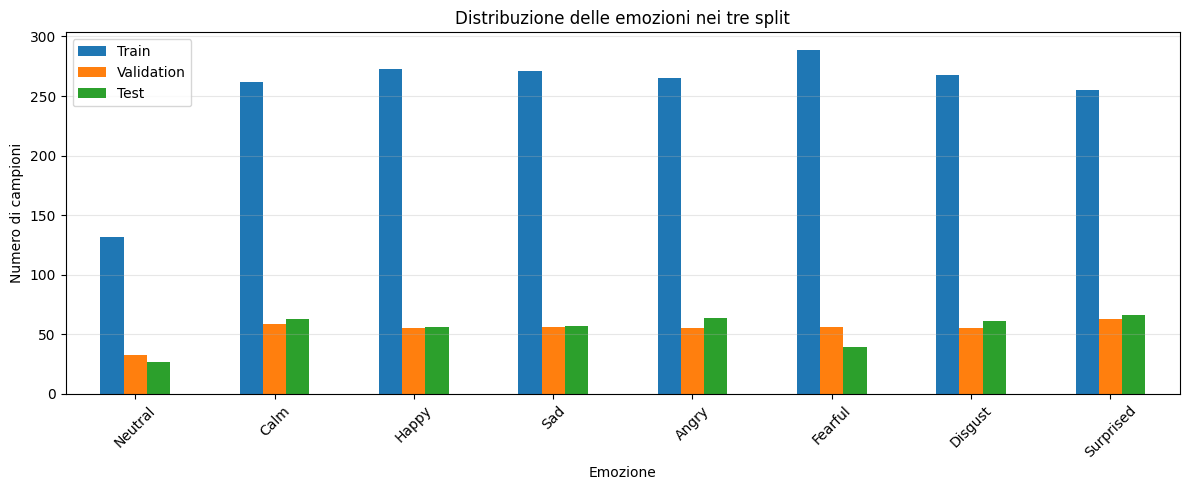

In [7]:



def _extract_labels_from_dataset(ds):
    """Estrae le label senza caricare gli audio, leggendo i nomi dei file RAVDESS."""
    if hasattr(ds, "indices") and hasattr(ds, "dataset"):
        base_dataset = ds.dataset
        indices = ds.indices
    else:
        base_dataset = ds
        indices = range(len(ds))

    labels = []
    for idx in indices:
        file_path = base_dataset._walker[idx]
        filename = os.path.basename(file_path)
        parts = filename.replace(".wav", "").split("-")
        labels.append(int(parts[2]) - 1)
    return labels

split_labels = {
    "Train": _extract_labels_from_dataset(train_dataset),
    "Validation": _extract_labels_from_dataset(val_dataset),
    "Test": _extract_labels_from_dataset(test_dataset),
}

split_counts = pd.DataFrame({
    split: pd.Series(labels).value_counts().sort_index()
    for split, labels in split_labels.items()
}).fillna(0).astype(int)


split_counts.index = [emotion_map.get(int(i), str(i)) for i in split_counts.index]

display(split_counts)

ax = split_counts.plot(kind="bar", figsize=(12, 5), rot=45)
ax.set_title("Distribuzione delle emozioni nei tre split")
ax.set_xlabel("Emozione")
ax.set_ylabel("Numero di campioni")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Dashboard audio del campione

Questa cella mostra insieme forma d'onda, Log-Mel Spectrogram e MFCC dello stesso campione. Serve a documentare visivamente il preprocessing audio usato nella baseline.


Campione: 1
Speaker: 15 | Utterance: 2 | Label: Calm
Waveform shape: (1, 41472) | Sample rate: 16000 Hz
Log-Mel shape: (1, 128, 260) | MFCC shape: (1, 40, 260)


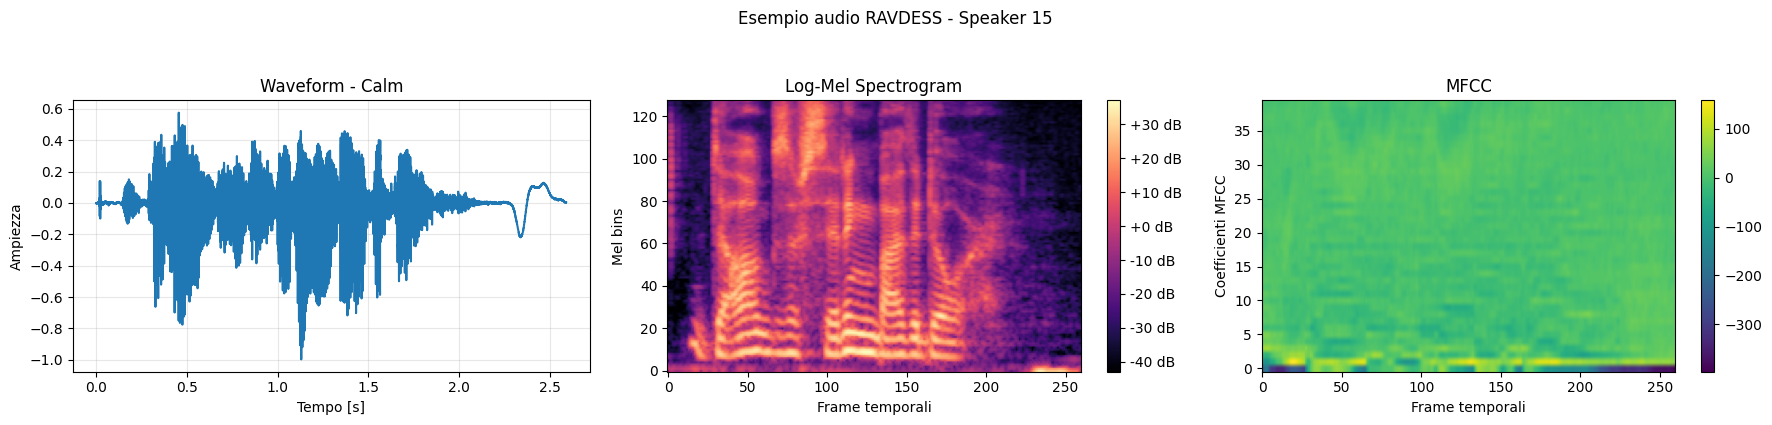

In [8]:



sample_idx = 1
waveform_vis, sr_vis, label_vis, speaker_vis, utt_vis = train_dataset[sample_idx]


TARGET_SAMPLE_RATE = 16000
if sr_vis != TARGET_SAMPLE_RATE:
    waveform_vis = T.Resample(orig_freq=sr_vis, new_freq=TARGET_SAMPLE_RATE)(waveform_vis)
    sr_vis = TARGET_SAMPLE_RATE


mel_transform_vis = T.MelSpectrogram(
    sample_rate=sr_vis,
    n_fft=1024,
    win_length=1024,
    hop_length=160,
    n_mels=128,
    power=2.0,
)
to_db_vis = T.AmplitudeToDB(stype="power", top_db=80)
mfcc_transform_vis = T.MFCC(
    sample_rate=sr_vis,
    n_mfcc=40,
    melkwargs={
        "n_fft": 1024,
        "win_length": 1024,
        "hop_length": 160,
        "n_mels": 128,
    },
)

logmel_vis = to_db_vis(mel_transform_vis(waveform_vis))
mfcc_vis = mfcc_transform_vis(waveform_vis)
time_axis = torch.arange(waveform_vis.shape[-1]) / sr_vis
emotion_name = emotion_map.get(int(label_vis), str(label_vis))

print(f"Campione: {sample_idx}")
print(f"Speaker: {speaker_vis} | Utterance: {utt_vis} | Label: {emotion_name}")
print(f"Waveform shape: {tuple(waveform_vis.shape)} | Sample rate: {sr_vis} Hz")
print(f"Log-Mel shape: {tuple(logmel_vis.shape)} | MFCC shape: {tuple(mfcc_vis.shape)}")

fig, axs = plt.subplots(1, 3, figsize=(18, 4))

axs[0].plot(time_axis.numpy(), waveform_vis[0].numpy())
axs[0].set_title(f"Waveform - {emotion_name}")
axs[0].set_xlabel("Tempo [s]")
axs[0].set_ylabel("Ampiezza")
axs[0].grid(alpha=0.3)

im1 = axs[1].imshow(logmel_vis[0].numpy(), origin="lower", aspect="auto", cmap="magma")
axs[1].set_title("Log-Mel Spectrogram")
axs[1].set_xlabel("Frame temporali")
axs[1].set_ylabel("Mel bins")
fig.colorbar(im1, ax=axs[1], format="%+2.0f dB")

im2 = axs[2].imshow(mfcc_vis[0].numpy(), origin="lower", aspect="auto", cmap="viridis")
axs[2].set_title("MFCC")
axs[2].set_xlabel("Frame temporali")
axs[2].set_ylabel("Coefficienti MFCC")
fig.colorbar(im2, ax=axs[2])

plt.suptitle(f"Esempio audio RAVDESS - Speaker {speaker_vis}", y=1.05)
plt.tight_layout()
plt.show()

ipd.display(ipd.Audio(waveform_vis.numpy(), rate=sr_vis))

# Preprocessing e feature extraction

Il dataset viene convertito in mono, normalizzato e ricampionato a 16 kHz dentro `RavdessDataset`.  
Qui definiamo una sola volta le trasformazioni usate dalla pipeline: spettrogramma, scala Mel, conversione in dB e MFCC per eventuali analisi.


In [9]:

TARGET_SAMPLE_RATE = 16000
n_fft = 1024
win_length = n_fft
hop_length = 160
n_mels = 128
n_mfcc = 40

specgramFn = T.Spectrogram(
    n_fft=n_fft,
    win_length=win_length,
    hop_length=hop_length,
    power=2.0,
)

melscaleFn = T.MelScale(
    n_mels=n_mels,
    sample_rate=TARGET_SAMPLE_RATE,
    n_stft=n_fft // 2 + 1,
)

amplitude_to_db_transform = T.AmplitudeToDB(stype="power", top_db=80)

mfccFn = T.MFCC(
    sample_rate=TARGET_SAMPLE_RATE,
    n_mfcc=n_mfcc,
    melkwargs={
        "n_fft": n_fft,
        "win_length": win_length,
        "hop_length": hop_length,
        "n_mels": n_mels,
    },
)

print("Trasformazioni audio definite:")
print(f"- Sample rate target: {TARGET_SAMPLE_RATE} Hz")
print(f"- n_fft={n_fft}, hop_length={hop_length}, n_mels={n_mels}, n_mfcc={n_mfcc}")

Trasformazioni audio definite:
- Sample rate target: 16000 Hz
- n_fft=1024, hop_length=160, n_mels=128, n_mfcc=40


# Formattazione dei dati

Le funzioni `label_to_index` e `index_to_label` vengono usate per mappare ogni etichetta nella rispettiva classe numerica e viceversa.


In [10]:


inverse_emotion_map = {v.lower(): k for k, v in emotion_map.items()}

def label_to_index(word):
    return torch.tensor(inverse_emotion_map[word.lower()])

def index_to_label(index):
    if torch.is_tensor(index): index = index.item()
    return emotion_map.get(index, f"Unknown ({index})")


w = 'Calm'; print(f"{w} → {label_to_index(w)} → {index_to_label(label_to_index(w))}")


Calm → 1 → Calm


## Segmentazione delle registrazioni audio

Prima di calcolare il Mel-spectrogram, ogni audio viene diviso in segmenti di durata fissa pari a **3 secondi** con **50% di overlap**. Se un file è più corto di 3 secondi viene completato con zero-padding; se è più lungo vengono generati più segmenti, tutti con la stessa label dell'utterance originale.

Questa modifica aumenta il numero effettivo di esempi visti dal modello e rende gli input più omogenei, mantenendo invariata l'architettura CRNN e il resto della pipeline.


In [11]:



_resizeFn = torchvision.transforms.Resize((64, 128))








SEGMENT_SECONDS = 3.0
SEGMENT_OVERLAP = 0.50
SEGMENT_SAMPLE_RATE = 16000
SEGMENT_LENGTH = int(SEGMENT_SECONDS * SEGMENT_SAMPLE_RATE)
SEGMENT_HOP = int(SEGMENT_LENGTH * (1.0 - SEGMENT_OVERLAP))


def segment_waveform(waveform, segment_length=SEGMENT_LENGTH, hop_length=SEGMENT_HOP):
    """
    Divide una waveform mono [1, T] in segmenti [1, segment_length].
    - Se l'audio è più corto del segmento, viene fatto zero-padding.
    - Se l'audio è più lungo, vengono creati segmenti sovrapposti.
    - L'ultimo segmento viene incluso e paddato se necessario, così non si perde
      la parte finale della registrazione.
    """
    if waveform.dim() != 2:
        raise ValueError(f"Attesa waveform con shape [canali, tempo], ricevuta {waveform.shape}")

    num_samples = waveform.shape[1]


    if num_samples <= segment_length:
        pad_amount = segment_length - num_samples
        padded = F.pad(waveform, (0, pad_amount))
        return [padded]

    segments = []
    start = 0

    while start < num_samples:
        end = start + segment_length
        segment = waveform[:, start:end]

        if segment.shape[1] < segment_length:
            segment = F.pad(segment, (0, segment_length - segment.shape[1]))

        segments.append(segment)


        if end >= num_samples:
            break

        start += hop_length

    return segments


def pad_sequence(batch):


    batch = [item.t() for item in batch]
    batch = torch.nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0.)
    return batch.permute(0, 2, 1)


def collate_fn(batch):
    tensors, targets = [], []

    for data in batch:
        waveform = data[0]
        label = data[2]


        segments = segment_waveform(waveform)

        for segment in segments:
            tensors.append(segment)
            targets.append(label)


    padded_waveforms = pad_sequence(tensors)

    spec_tensors = specgramFn(padded_waveforms)
    melspec_tensors = melscaleFn(spec_tensors)
    db_melspec_tensors = amplitude_to_db_transform(melspec_tensors)

    mel = _resizeFn(db_melspec_tensors)

    targets = torch.stack(targets)

    return mel, targets


batch_size = 64

if device.type == "cuda":
    num_workers = 1
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

print("Segmentazione attiva")
print(f"Durata segmento: {SEGMENT_SECONDS:.1f}s ({SEGMENT_LENGTH} campioni a {SEGMENT_SAMPLE_RATE} Hz)")
print(f"Overlap: {SEGMENT_OVERLAP*100:.0f}% | Hop: {SEGMENT_HOP} campioni")



Segmentazione attiva
Durata segmento: 3.0s (48000 campioni a 16000 Hz)
Overlap: 50% | Hop: 24000 campioni


## Verifica dell'input della CRNN

Questa cella controlla che il `DataLoader` produca tensori nel formato atteso dal modello: `[batch, canali, frequenze, tempo]`.


Batch input shape: (64, 1, 64, 128)
Batch target shape: (64,)
Esempio label: Sad


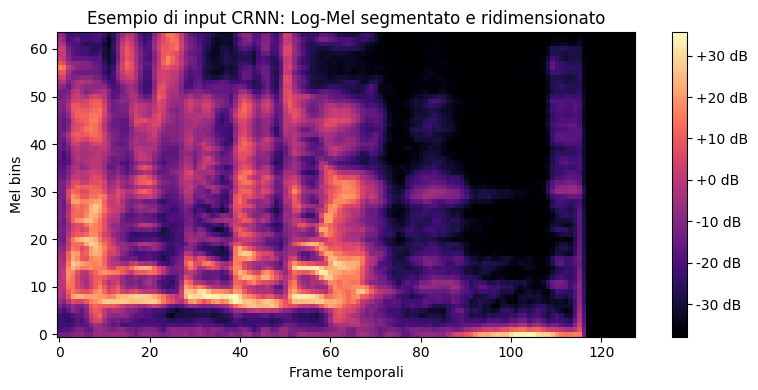

In [12]:
example_batch, example_targets = next(iter(train_loader))

print(f"Batch input shape: {tuple(example_batch.shape)}")
print(f"Batch target shape: {tuple(example_targets.shape)}")
print(f"Esempio label: {emotion_map.get(int(example_targets[0]), str(int(example_targets[0])))}")

plt.figure(figsize=(8, 4))
plt.imshow(example_batch[0, 0].cpu().numpy(), origin="lower", aspect="auto", cmap="magma")
plt.title("Esempio di input CRNN: Log-Mel segmentato e ridimensionato")
plt.xlabel("Frame temporali")
plt.ylabel("Mel bins")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()

## Funzioni generiche per training e validazione

Questa sezione definisce una funzione generica di training che passa i dati al modello, calcola la loss, esegue la backpropagation e aggiorna i pesi tramite l'ottimizzatore.

La funzione riceve come parametri:
- la trasformazione da applicare ai dati, se presente;
- la funzione di loss;
- l'ottimizzatore da usare durante il training.


In [13]:

def train(model, transform, criterion, optimizer, epoch, log_interval, scheduler=None):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data = data.to(device)
        target = target.to(device)


        if transform is not None:
            data = data.contiguous()
            data = transform(data)


        output = model(data)
        loss = criterion(output, target)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        if scheduler is not None:
            scheduler.step()


        batch_size_curr = target.size(0)
        running_loss += loss.item() * batch_size_curr
        pred = get_likely_index(output)
        correct += number_of_correct(pred, target)
        total += batch_size_curr

        if batch_idx % log_interval == 0:
            print()
            print(f"       Train Epoch: {epoch} [batch {batch_idx + 1}/{len(train_loader)} ({100. * (batch_idx + 1) / len(train_loader):.0f}%)]")
            print(f"       Batch loss: {loss.item():.6f}")

        pbar.update(pbar_update)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    print(f"Train Epoch: {epoch}\tAverage loss: {epoch_loss:.4f}\tAccuracy: {correct}/{total} ({epoch_acc:.2f}%)")

    return epoch_loss, epoch_acc


## Funzione generica di valutazione

Dopo aver definito la funzione di training, viene definita una funzione generica per valutare l'accuratezza del modello. Il modello viene impostato in modalità `eval()` prima dell'inferenza, in modo che layer come dropout e batch normalization si comportino correttamente durante la valutazione.


In [14]:

def number_of_correct(pred, target):

    return pred.squeeze().eq(target).sum().item()


def get_likely_index(tensor):

    return tensor.argmax(dim=-1)


def evaluate_epoch(model, data_loader, transform, criterion, epoch=None, split_name="Validation"):
    """
    Valuta il modello su un loader e restituisce loss media e accuracy percentuale.
    La uso durante il training per costruire le curve train/validation.
    """
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)
            target = target.to(device)

            if transform is not None:
                data = data.contiguous()
                data = transform(data)

            output = model(data)
            loss = criterion(output, target)
            pred = get_likely_index(output)

            batch_size_curr = target.size(0)
            running_loss += loss.item() * batch_size_curr
            correct += number_of_correct(pred, target)
            total += batch_size_curr

            pbar.update(pbar_update)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    if epoch is not None:
        print(f"{split_name} Epoch: {epoch}\tAverage loss: {epoch_loss:.4f}\tAccuracy: {correct}/{total} ({epoch_acc:.2f}%)\n")
    else:
        print(f"{split_name}\tAverage loss: {epoch_loss:.4f}\tAccuracy: {correct}/{total} ({epoch_acc:.2f}%)\n")

    return epoch_loss, epoch_acc


def test(model, transform, criterion, epoch):

    return evaluate_epoch(model, test_loader, transform, criterion, epoch=epoch, split_name="Test")


## Funzioni di valutazione finale segment-level e utterance-level

Questa sezione definisce le funzioni per calcolare le metriche finali. La valutazione segment-level usa i segmenti prodotti dal `DataLoader`, mentre la valutazione utterance-level aggrega le predizioni dei segmenti appartenenti alla stessa registrazione audio tramite media delle probabilità softmax.


In [15]:

def evaluate_model(model, data_loader, device, transform=None, classes=None, split_name="Test"):

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)
            target = target.to(device)

            if transform is not None:
                data = data.contiguous()
                data = transform(data)

            output = model(data)
            preds = output.argmax(dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    error = 1.0 - acc
    f1 = f1_score(all_targets, all_preds, average='macro')
    cm = confusion_matrix(all_targets, all_preds)

    print("\n" + "="*45)
    print(f"RISULTATI FINALI SEGMENT-LEVEL SUL {split_name.upper()} SET")
    print("="*45)
    print(f"Accuracy Generale: {acc * 100:.2f}%")
    print(f"Error Rate: {error * 100:.2f}%")
    print(f"F1-Score (Macro): {f1:.4f}")

    if classes is None:
        classes = [emotion_map[i] for i in range(len(cm))]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )
    plt.xlabel('Predizione del Modello')
    plt.ylabel('Emozione Reale')
    plt.title(f'Matrice di Confusione Segment-Level - {split_name}')
    plt.tight_layout()
    plt.show()

    return acc, f1, cm


def evaluate_utterance_level(model, dataset, device, transform=None, classes=None, split_name="Test"):

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data in dataset:
            waveform = data[0]
            target = int(data[2])

            segments = segment_waveform(waveform)
            padded_waveforms = pad_sequence(segments)

            spec_tensors = specgramFn(padded_waveforms)
            melspec_tensors = melscaleFn(spec_tensors)
            db_melspec_tensors = amplitude_to_db_transform(melspec_tensors)
            mel = _resizeFn(db_melspec_tensors).to(device)

            if transform is not None:
                mel = mel.contiguous()
                mel = transform(mel)

            output = model(mel)
            probs = torch.softmax(output, dim=-1)
            mean_probs = probs.mean(dim=0)
            pred = int(mean_probs.argmax().cpu().item())

            all_preds.append(pred)
            all_targets.append(target)

    acc = accuracy_score(all_targets, all_preds)
    error = 1.0 - acc
    f1 = f1_score(all_targets, all_preds, average='macro')
    cm = confusion_matrix(all_targets, all_preds)

    print("\n" + "="*55)
    print(f"RISULTATI FINALI UTTERANCE-LEVEL SUL {split_name.upper()} SET")
    print("="*55)
    print(f"Numero utterance valutate: {len(all_targets)}")
    print(f"Accuracy Generale: {acc * 100:.2f}%")
    print(f"Error Rate: {error * 100:.2f}%")
    print(f"F1-Score (Macro): {f1:.4f}")

    if classes is None:
        classes = [emotion_map[i] for i in range(len(cm))]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )
    plt.xlabel('Predizione del Modello')
    plt.ylabel('Emozione Reale')
    plt.title(f'Matrice di Confusione Utterance-Level - {split_name}')
    plt.tight_layout()
    plt.show()

    return acc, f1, cm


# Parte 1


# Modello di rete


In [16]:

class CRNN(nn.Module):
    """
    CRNN Architecture (Choi et al., 2016):
    - 4x Conv2D (3x3 kernel) + BatchNorm + ELU + MaxPool + Dropout(0.1)
    - AdaptiveAvgPool2d -> (freq=1, time=8)
    - 2-layer GRU
    - Last hidden state -> FC -> num_classes

    Input: (batch, 1, n_mels, time_frames)  [mel-spectrogram]
    Output: (batch, num_classes)            [logit scores]
    """

    def __init__(self, num_classes: int, n_channels: int = 68,
                 rnn_hidden: int = 68, rnn_layers: int = 2,
                 dropout: float = 0.1):
        super().__init__()












        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1,              n_channels,   kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(2, 2)),
            nn.Dropout(dropout),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(n_channels,   n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(2, 2)),
            nn.Dropout(dropout),
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(n_channels*2, n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(4, 2)),
            nn.Dropout(dropout),
        )
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(n_channels*2, n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(4, 2)),
            nn.Dropout(dropout),
        )


        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 8))




        self.rnn = nn.GRU(
            input_size=n_channels * 2,
            hidden_size=rnn_hidden,
            num_layers=rnn_layers,
            batch_first=True,
            dropout=dropout if rnn_layers > 1 else 0.0,
        )




        self.fc = nn.Linear(rnn_hidden, num_classes)

    def forward(self, x):



        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)


        x = self.adaptive_pool(x)
        x = x.squeeze(2)


        x = x.permute(0, 2, 1)



        _, h_n = self.rnn(x)
        x = h_n[-1]


        return self.fc(x)



NUMERO_EMOZIONI = 8

model_crnn = CRNN(
    num_classes=NUMERO_EMOZIONI,
    n_channels=68,
    rnn_hidden=68,
    rnn_layers=2,
    dropout=0.1
)

_dummy = torch.zeros(2, 1, 64, 128)
with torch.no_grad():
    _out = model_crnn(_dummy)
print(f"Shape check  →  input: {list(_dummy.shape)}   output: {list(_out.shape)}")
assert _out.shape == (2, NUMERO_EMOZIONI), "Shape mismatch!"
print("Forward pass OK\n")

total_params = sum(p.numel() for p in model_crnn.parameters() if p.requires_grad)
print(f"Variante:          0.5M  (n_channels=68, rnn_hidden=68)")
print(f"Parametri totali:  {total_params:,}")
print()
print(model_crnn)

Shape check  →  input: [2, 1, 64, 128]   output: [2, 8]
Forward pass OK

Variante:          0.5M  (n_channels=68, rnn_hidden=68)
Parametri totali:  488,928

CRNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 68, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(68, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.1, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(68, 136, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(136, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.1, inplace=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(136, 136, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(1

## Visualizzazione dell'architettura del modello

Sono mantenute solo le visualizzazioni più leggibili: schema a blocchi, summary, shape flow e grafo `torchview` opzionale. Il grafo computazionale completo è stato rimosso perché troppo dettagliato e poco utile per il report.


In [17]:



print("Summary del modello CRNN con input (1, 64, 128):")
print()


if 'summary' in globals() and summary is not None:
    try:

        _summary_device = "cpu"
        model_crnn = model_crnn.to(_summary_device)
        summary(model_crnn, input_size=(1, 64, 128), device=_summary_device)
    except Exception as e:
        print("Impossibile generare il summary con torchsummary.")
        print("Motivo:", repr(e))



Summary del modello CRNN con input (1, 64, 128):

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 68, 64, 128]             680
       BatchNorm2d-2          [-1, 68, 64, 128]             136
               ELU-3          [-1, 68, 64, 128]               0
         MaxPool2d-4           [-1, 68, 32, 64]               0
           Dropout-5           [-1, 68, 32, 64]               0
            Conv2d-6          [-1, 136, 32, 64]          83,368
       BatchNorm2d-7          [-1, 136, 32, 64]             272
               ELU-8          [-1, 136, 32, 64]               0
         MaxPool2d-9          [-1, 136, 16, 32]               0
          Dropout-10          [-1, 136, 16, 32]               0
           Conv2d-11          [-1, 136, 16, 32]         166,600
      BatchNorm2d-12          [-1, 136, 16, 32]             272
              ELU-13          [-1, 136, 16, 32]      

In [18]:




def print_crnn_shape_flow(model, input_shape=(1, 1, 64, 128)):
    """Stampa le shape principali attraversate da un input dummy nella CRNN."""
    model_cpu = model.to("cpu").eval()
    x = torch.zeros(*input_shape)

    print(f"Input:              {tuple(x.shape)}")
    with torch.no_grad():
        x = model_cpu.conv_block1(x)
        print(f"Dopo conv_block1:   {tuple(x.shape)}")
        x = model_cpu.conv_block2(x)
        print(f"Dopo conv_block2:   {tuple(x.shape)}")
        x = model_cpu.conv_block3(x)
        print(f"Dopo conv_block3:   {tuple(x.shape)}")
        x = model_cpu.conv_block4(x)
        print(f"Dopo conv_block4:   {tuple(x.shape)}")
        x = model_cpu.adaptive_pool(x)
        print(f"Dopo adaptive_pool: {tuple(x.shape)}")
        x = x.squeeze(2)
        print(f"Dopo squeeze freq:  {tuple(x.shape)}")
        x = x.permute(0, 2, 1)
        print(f"Input GRU:          {tuple(x.shape)}")
        _, h_n = model_cpu.rnn(x)
        print(f"Hidden GRU h_n:     {tuple(h_n.shape)}")
        x = h_n[-1]
        print(f"Last hidden state:  {tuple(x.shape)}")
        out = model_cpu.fc(x)
        print(f"Output logits:      {tuple(out.shape)}")

print_crnn_shape_flow(model_crnn)


Input:              (1, 1, 64, 128)
Dopo conv_block1:   (1, 68, 32, 64)
Dopo conv_block2:   (1, 136, 16, 32)
Dopo conv_block3:   (1, 136, 4, 16)
Dopo conv_block4:   (1, 136, 1, 8)
Dopo adaptive_pool: (1, 136, 1, 8)
Dopo squeeze freq:  (1, 136, 8)
Input GRU:          (1, 8, 136)
Hidden GRU h_n:     (2, 1, 68)
Last hidden state:  (1, 68)
Output logits:      (1, 8)


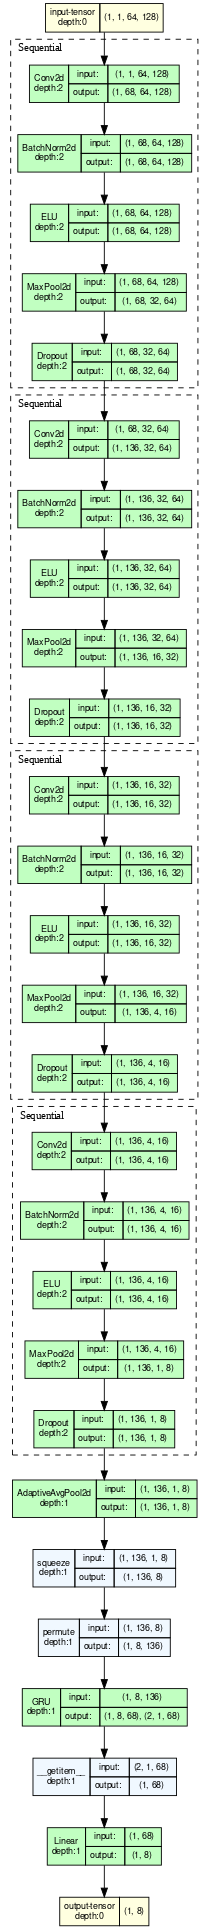

In [19]:







model_cpu = model_crnn.to("cpu").eval()
model_graph = draw_graph(
    model_cpu,
    input_size=(1, 1, 64, 128),
    device="cpu",
    expand_nested=True,
    save_graph=False,
)

model_graph.visual_graph


# Training e testing


In [20]:

import copy


model = model_crnn
transform = None
criterion = nn.CrossEntropyLoss()

log_interval = 20
n_epoch = 30


optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.001,
    steps_per_epoch=len(train_loader),
    epochs=n_epoch,
    anneal_strategy='linear'
)

model = model.to(device)



pbar_update = 1 / (len(train_loader) + len(val_loader))

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}




best_val_loss = float("inf")
best_val_acc = 0.0
best_epoch = 0
best_model_state = None

print(f"Device: {device}")
print(f"Parametri totali: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print()

with tqdm(total=n_epoch) as pbar:
    for epoch in range(1, n_epoch + 1):
        train_loss, train_acc = train(model, transform, criterion, optimizer, epoch, log_interval, scheduler)
        val_loss, val_acc = evaluate_epoch(model, val_loader, transform, criterion, epoch=epoch, split_name="Validation")

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"Nuovo best model salvato all'epoch {best_epoch} "
                  f"(val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.2f}%)")


if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nBest model ripristinato: epoch {best_epoch} "
          f"(val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.2f}%)")


Device: cuda
Parametri totali: 488,928



  0%|          | 0.02564102564102564/30 [00:03<1:08:33, 137.23s/it]


       Train Epoch: 1 [batch 1/32 (3%)]
       Batch loss: 2.049480


  2%|▏         | 0.5384615384615387/30 [00:48<42:27, 86.46s/it]


       Train Epoch: 1 [batch 21/32 (66%)]
       Batch loss: 2.038232


...


       Train Epoch: 30 [batch 21/32 (66%)]
       Batch loss: 0.029866


 99%|█████████▉| 29.82051282051272/30 [27:04<00:08, 44.79s/it] 

Train Epoch: 30	Average loss: 0.0285	Accuracy: 2046/2057 (99.47%)


100%|█████████▉| 29.9999999999999/30 [27:13<00:00, 54.45s/it]

Validation Epoch: 30	Average loss: 0.3370	Accuracy: 397/438 (90.64%)


Best model ripristinato: epoch 28 (val_loss=0.3348, val_acc=91.55%)


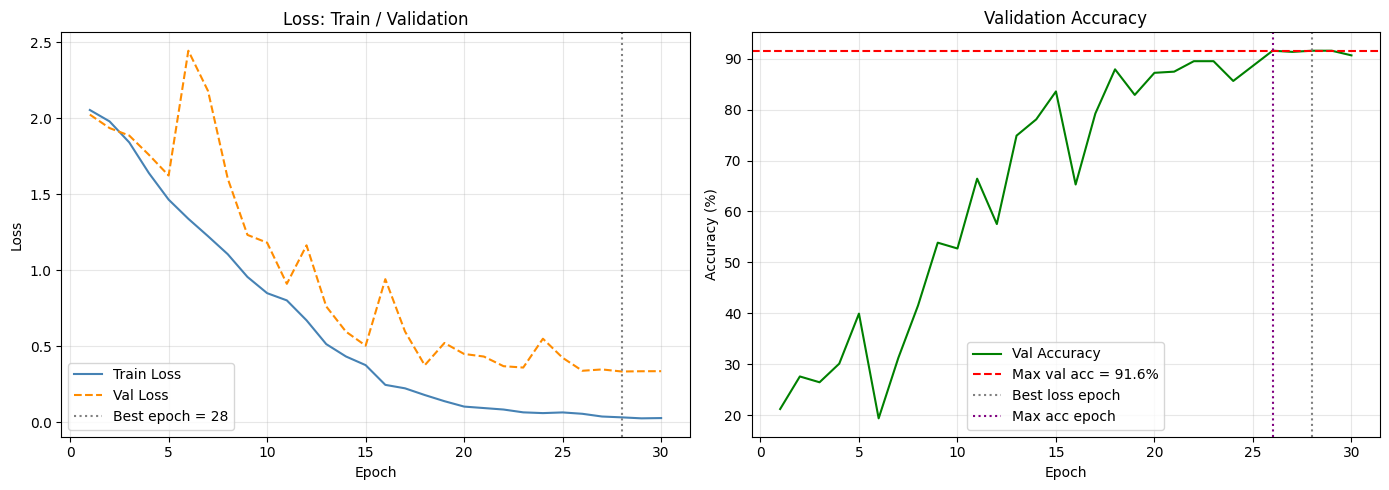

Final train loss: 0.0285 | Final train acc: 99.47%
Final val loss:   0.3370 | Final val acc:   90.64%


In [21]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', color='darkorange', linestyle='--')

if best_epoch > 0:
    axes[0].axvline(best_epoch, color='gray', linestyle=':', label=f'Best epoch = {best_epoch}')

axes[0].set_title('Loss: Train / Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['val_acc'], color='green', label='Val Accuracy')

plot_max_val_acc = max(history['val_acc']) if history['val_acc'] else 0.0
plot_max_val_acc_epoch = history['val_acc'].index(plot_max_val_acc) + 1 if history['val_acc'] else 0
axes[1].axhline(
    y=plot_max_val_acc,
    color='red',
    linestyle='--',
    label=f'Max val acc = {plot_max_val_acc:.1f}%'
)

if best_epoch > 0:
    axes[1].axvline(best_epoch, color='gray', linestyle=':', label='Best loss epoch')
if plot_max_val_acc_epoch > 0:
    axes[1].axvline(plot_max_val_acc_epoch, color='purple', linestyle=':', label='Max acc epoch')

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.4f} | Final train acc: {history['train_acc'][-1]:.2f}%")
print(f"Final val loss:   {history['val_loss'][-1]:.4f} | Final val acc:   {history['val_acc'][-1]:.2f}%")


Best model usato per la valutazione finale: epoch 28


RISULTATI FINALI SEGMENT-LEVEL SUL VALIDATION SET
Accuracy Generale: 91.55%
Error Rate: 8.45%
F1-Score (Macro): 0.9144


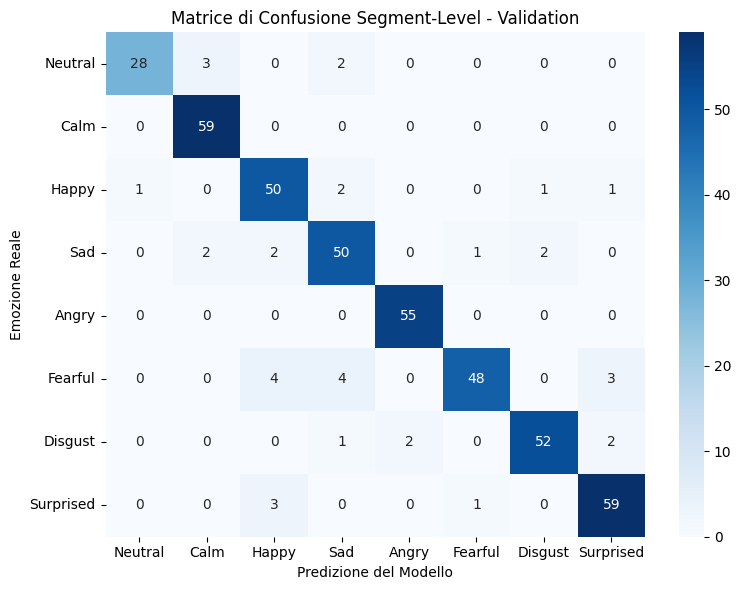



RISULTATI FINALI SEGMENT-LEVEL SUL TEST SET
Accuracy Generale: 92.97%
Error Rate: 7.03%
F1-Score (Macro): 0.9177


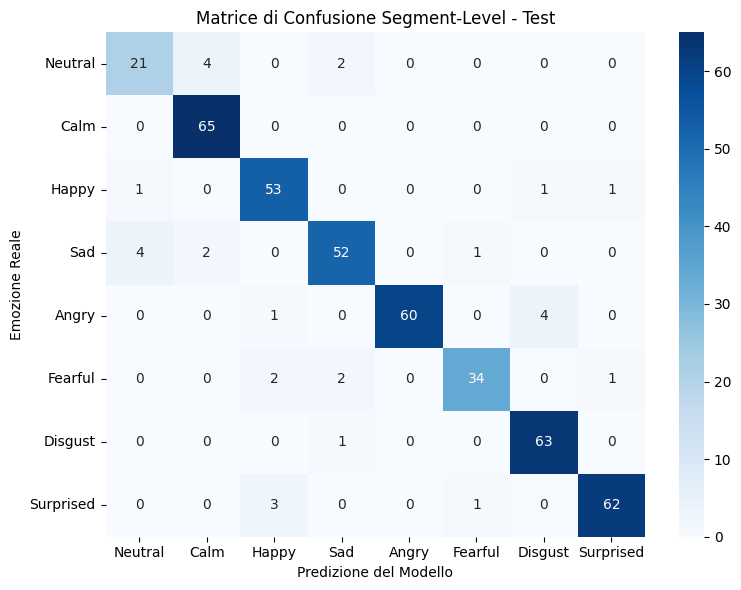



RISULTATI FINALI UTTERANCE-LEVEL SUL VALIDATION SET
Numero utterance valutate: 432
Accuracy Generale: 91.44%
Error Rate: 8.56%
F1-Score (Macro): 0.9129


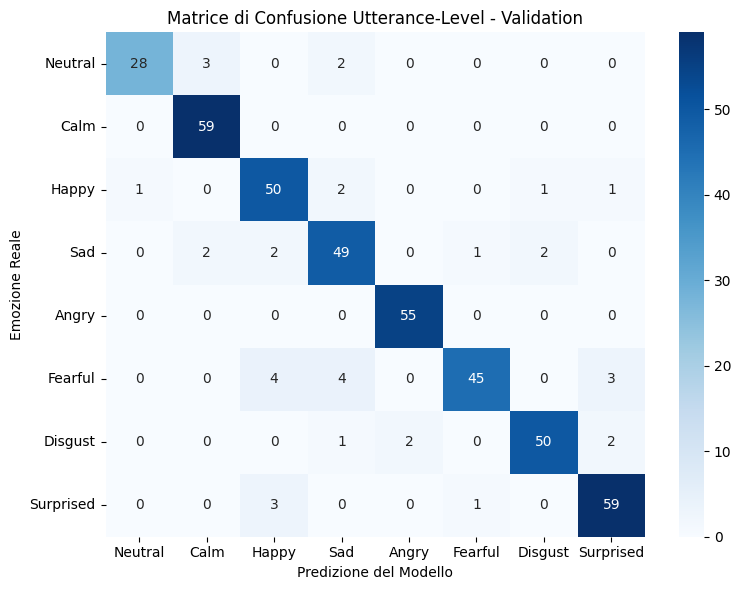



RISULTATI FINALI UTTERANCE-LEVEL SUL TEST SET
Numero utterance valutate: 433
Accuracy Generale: 92.84%
Error Rate: 7.16%
F1-Score (Macro): 0.9167


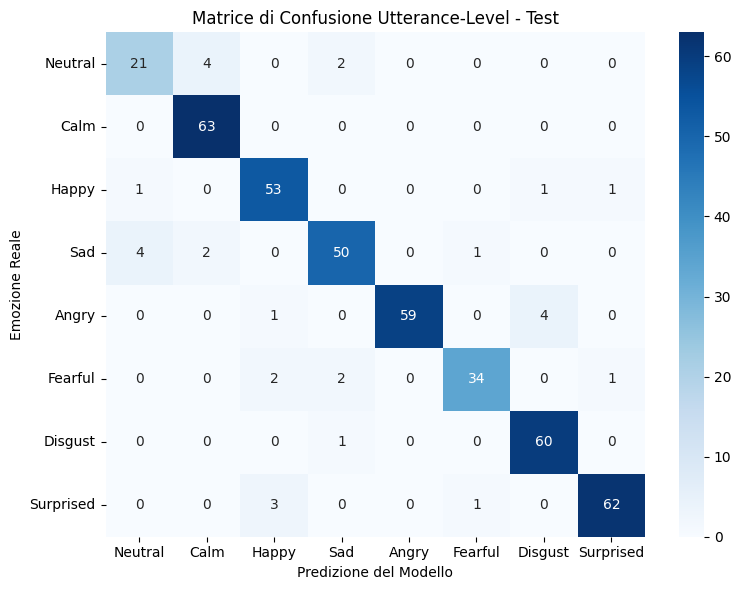

In [22]:

print(f"Best model usato per la valutazione finale: epoch {best_epoch}")

classes = [emotion_map[i] for i in range(8)]

print()
val_seg_acc, val_seg_f1, val_seg_cm = evaluate_model(
    model,
    val_loader,
    device,
    transform=None,
    classes=classes,
    split_name="Validation"
)

print()
test_seg_acc, test_seg_f1, test_seg_cm = evaluate_model(
    model,
    test_loader,
    device,
    transform=None,
    classes=classes,
    split_name="Test"
)

print()
val_utt_acc, val_utt_f1, val_utt_cm = evaluate_utterance_level(
    model,
    val_dataset,
    device,
    transform=None,
    classes=classes,
    split_name="Validation"
)

print()
test_utt_acc, test_utt_f1, test_utt_cm = evaluate_utterance_level(
    model,
    test_dataset,
    device,
    transform=None,
    classes=classes,
    split_name="Test"
)
